In [16]:
import transformers
from transformers import AutoTokenizer, AutoModelForSequenceClassification, DistilBertTokenizer, DistilBertForSequenceClassification
import torch


In [25]:
#distilbert speichern, geature engineering 
#modell laden
#bert gespeichert unter model/distilbert-base-uncased

from transformers import DistilBertModel, DistilBertTokenizer

MODEL_PATH = "./model/distilbert-base-uncased/"
bert_model = DistilBertModel.from_pretrained(MODEL_PATH)
tokenizer = DistilBertTokenizer.from_pretrained(MODEL_PATH)


KeyboardInterrupt: 

In [ ]:
#distilbert testen
# Text tokenisieren und in IDs umwandeln
text = "Hey its me Mario"
# Tokenisierung
tokens = tokenizer.tokenize(text)
print("Tokens:", tokens)

# Token zu IDs
token_ids = tokenizer.encode(text)
print("Token IDs:", token_ids)

# Komplette Tokenisierung mit Padding und Attention Mask
encoded = tokenizer(text, padding=True, truncation=True, return_tensors="pt")
print("Vollständig encodiert:", encoded)

Tokens: ['hey', 'its', 'me', 'mario']
Token IDs: [101, 4931, 2049, 2033, 7986, 102]
Vollständig encodiert: {'input_ids': tensor([[ 101, 4931, 2049, 2033, 7986,  102]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1]])}


In [1]:
#EDA
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Daten laden
df = pd.read_csv('HateSpeechDatasetBalanced.csv')

# Erste Überprüfung
print("Datensatzinfo:")
print(df.info())
print("\nErste Zeilen:")
print(df.head())

Datensatzinfo:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 726119 entries, 0 to 726118
Data columns (total 2 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   Content  726119 non-null  object
 1   Label    726119 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 11.1+ MB
None

Erste Zeilen:
                                             Content  Label
0  denial of normal the con be asked to comment o...      1
1  just by being able to tweet this insufferable ...      1
2  that is retarded you too cute to be single tha...      1
3  thought of a real badass mongol style declarat...      1
4                                afro american basho      1


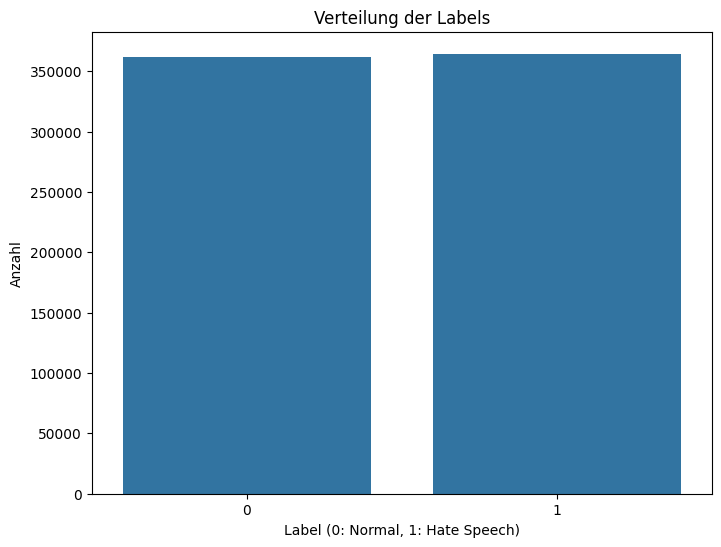

In [3]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Label')
plt.title('Verteilung der Labels')
plt.xlabel('Label (0: Normal, 1: Hate Speech)')
plt.ylabel('Anzahl')
plt.show()

/Users/luke/micromamba/lib/python3.9/site-packages/seaborn/categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


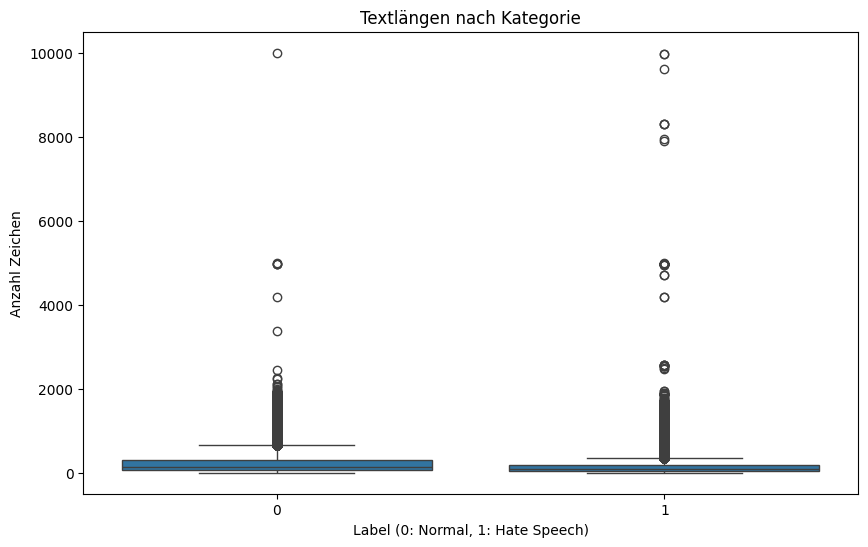

/Users/luke/micromamba/lib/python3.9/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/luke/micromamba/lib/python3.9/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/luke/micromamba/lib/python3.9/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


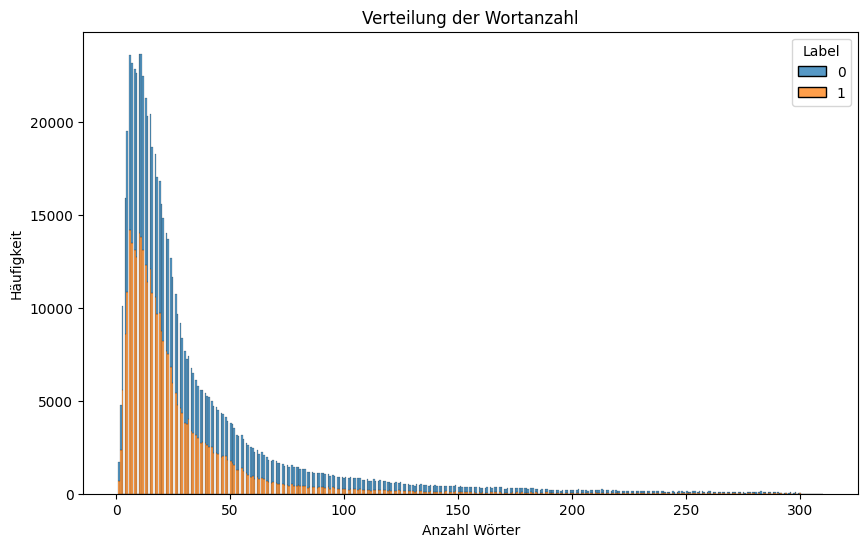

In [4]:
# Textlängen hinzufügen
df['text_length'] = df['Content'].str.len()
df['word_count'] = df['Content'].str.split().str.len()

# Boxplot der Textlängen
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Label', y='text_length')
plt.title('Textlängen nach Kategorie')
plt.xlabel('Label (0: Normal, 1: Hate Speech)')
plt.ylabel('Anzahl Zeichen')
plt.show()

# Verteilung der Wortanzahl
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='word_count', hue='Label', multiple="stack")
plt.title('Verteilung der Wortanzahl')
plt.xlabel('Anzahl Wörter')
plt.ylabel('Häufigkeit')
plt.show()

In [ ]:
##CODE FÜR TRAINING IN GOOGLE COLAB
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import torch
from transformers import DistilBertModel, DistilBertTokenizer
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
import os
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tqdm import tqdm


#pfade
DATA_PATH = "/content/drive/My Drive/"
CHECKPOINT_PATH = "/content/drive/My Drive/hate_speech_checkpoints/"
MODEL_PATH = "/content/drive/My Drive/hate_speech_model/"

# daten laden
df = pd.read_csv(f'{DATA_PATH}HateSpeechDatasetBalanced.csv')
texts = df['Content'].tolist()
labels = df['Label'].tolist()

print(f"Verwende {len(texts)} Samples aus dem Datensatz")

# split
train_texts, val_texts, train_labels, val_labels = train_test_split(texts, labels, test_size=0.2, random_state=42)

# distilbert, tokenizer (liegen lokal, aber für google online ziehen)
MODEL_NAME = "distilbert-base-uncased"
bert_model = DistilBertModel.from_pretrained(MODEL_NAME)
tokenizer = DistilBertTokenizer.from_pretrained(MODEL_NAME)


for param in bert_model.parameters():
    param.requires_grad = False #keine gewichtanpassen, modell wird praktisch eingefroren

# https://pytorch.org/docs/stable/generated/torch.nn.Sequential.html
# https://stackoverflow.com/questions/68606661/what-is-difference-between-nn-module-and-nn-sequential
# Feed Forward Layer
classifier = torch.nn.Sequential(
    torch.nn.Linear(768, 128),  #768 eingang, weil distilbert 768 ausgang (vektorgröße)
    torch.nn.ReLU(),       #relu aktivierungsfunktion; eingabe wird nicht-linear, komplexe mustererkennung   
    torch.nn.Dropout(0.1), #gegen overfitting; 10% dass neuron aussetzt
    torch.nn.Linear(128, 2) #128 eingabe aus vorheriger schicht, 2 die binäre klassifizierung
) 


#verwendung der GPU; CUDA wichtig, damit die T4 verwendet wird
device = torch.device("cuda")
bert_model.to(device)
classifier.to(device)

def load_checkpoint(checkpoint_path, optimizer):
    checkpoint = torch.load(checkpoint_path)
    classifier.load_state_dict(checkpoint['classifier_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    epoch = checkpoint['epoch']
    loss = checkpoint['loss']
    return epoch, loss

# Daten in Batches verarbeiten
def create_data_loader(texts, labels, batch_size):
    inputs = tokenizer(texts, return_tensors="pt", padding=True, truncation=True, max_length=128)
    labels = torch.tensor(labels)
    dataset = TensorDataset(inputs['input_ids'], inputs['attention_mask'], labels)
    return DataLoader(dataset, batch_size=batch_size, shuffle=True)

# prog bar
from tqdm import tqdm

# Orientierung für train function:
# https://gist.github.com/MLWhiz/2cd4712647f72d4078caf4d76b650717
# https://machinelearningmastery.com/managing-a-pytorch-training-process-with-checkpoints-and-early-stopping/
# https://stackoverflow.com/questions/60018578/what-does-model-eval-do-in-pytorch
# https://github.com/dusty-nv/pytorch-classification/blob/master/train.py
# https://gist.github.com/omarfsosa/2dca44aed9b699d935bd479e6c051180

def train(train_loader, val_loader, epochs=10, batch_size=128):
    optimizer = torch.optim.AdamW(classifier.parameters(), lr=2e-5)
    loss_fn = torch.nn.CrossEntropyLoss()

    start_epoch = 0
    if os.path.exists(f"{CHECKPOINT_PATH}checkpoint_latest.pt"):
        start_epoch, _ = load_checkpoint(f"{CHECKPOINT_PATH}checkpoint_latest.pt", optimizer)
        print(f"Lade Checkpoint von Epoche {start_epoch}")

    for epoch in range(start_epoch, epochs):
        print(f"Epoche {epoch+1}/{epochs}")
        running_loss = 0

        progress_bar = tqdm(train_loader, desc=f"Epoche {epoch+1}/{epochs}", leave=False)
        for batch in progress_bar:
            input_ids = batch[0].to(device)
            attention_mask = batch[1].to(device)
            labels = batch[2].to(device)

            with torch.no_grad():
                bert_output = bert_model(input_ids, attention_mask=attention_mask)
                features = bert_output.last_hidden_state[:, 0]

            outputs = classifier(features)
            loss = loss_fn(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            progress_bar.set_postfix({"Verlust": f"{running_loss / (progress_bar.n + 1):.4f}"})

        avg_train_loss = running_loss / len(train_loader)

        # Validation
        val_loss = 0
        val_preds = []
        val_true = []

        classifier.eval() #eval modus
        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch[0].to(device)
                attention_mask = batch[1].to(device)
                labels = batch[2].to(device)

                bert_output = bert_model(input_ids, attention_mask=attention_mask)
                features = bert_output.last_hidden_state[:, 0]

                outputs = classifier(features)
                loss = loss_fn(outputs, labels)
                val_loss += loss.item()

                preds = torch.argmax(outputs, dim=1)
                val_preds.extend(preds.cpu().numpy())
                val_true.extend(labels.cpu().numpy())

        avg_val_loss = val_loss / len(val_loader)

        val_accuracy = accuracy_score(val_true, val_preds)
        val_precision = precision_score(val_true, val_preds)
        val_recall = recall_score(val_true, val_preds)
        val_f1 = f1_score(val_true, val_preds)

        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}, Val Accuracy: {val_accuracy:.4f}, Val Precision: {val_precision:.4f}, Val Recall: {val_recall:.4f}, Val F1: {val_f1:.4f}")

        # Klassifikator speichern
        torch.save({
            'epoch': epoch+1,
            'classifier_state_dict': classifier.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': loss,
        }, f"{CHECKPOINT_PATH}checkpoint_epoch_{epoch+1}.pt")
        torch.save({
            'epoch': epoch+1,
            'classifier_state_dict': classifier.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': loss,
        }, f"{CHECKPOINT_PATH}checkpoint_latest.pt")

def predict(text):
    inputs = tokenizer(text, return_tensors="pt", padding=True, truncation=True, max_length=128)
    input_ids = inputs['input_ids'].to(device)
    attention_mask = inputs['attention_mask'].to(device)

    with torch.no_grad():
        bert_output = bert_model(input_ids, attention_mask=attention_mask)
        features = bert_output.last_hidden_state[:, 0]
        outputs = classifier(features)
        probabilities = torch.nn.functional.softmax(outputs, dim=1)

    return probabilities.cpu()


train_loader = create_data_loader(train_texts, train_labels, batch_size=128)
val_loader = create_data_loader(val_texts, val_labels, batch_size=128)

print("Starte Training...")
train(train_loader, val_loader, epochs=10)


print("Saving final classifier and tokenizer...")
torch.save(classifier.state_dict(), f"{MODEL_PATH}classifier_final.pt")
tokenizer.save_pretrained(f"{MODEL_PATH}tokenizer_final")

# Test-Beispiele
test_texts = [
    "I love this wonderful day!",
    "You stupid idiot",
    "Have a nice day",
    "I hate you all"
]

print("\nTeste Vorhersagen:")
for text in test_texts:
    result = predict(text)
    print(f"\nText: {text}")
    print(f"Normal Speech: {result[0][0]:.3f}, Hate Speech: {result[0][1]:.3f}")

ModuleNotFoundError: No module named 'google.colab'

In [ ]:
### Ab hier TESTS, training war in Google Colab mit T4

# 

import torch
from transformers import DistilBertModel, DistilBertTokenizer

MODEL_PATH = "hate_speech_model/"

bert_model = DistilBertModel.from_pretrained("./model/distilbert-base-uncased/")

# https://pytorch.org/docs/stable/generated/torch.nn.Sequential.html
# https://stackoverflow.com/questions/68606661/what-is-difference-between-nn-module-and-nn-sequential
# Feed Forward Layer
classifier = torch.nn.Sequential(
    torch.nn.Linear(768, 256),  #768 eingang, weil distilbert 768 ausgang (vektorgröße)
    torch.nn.ReLU(),       #relu aktivierungsfunktion; eingabe wird nicht-linear, komplexe mustererkennung   
    torch.nn.Dropout(0.1), #gegen overfitting; 10% dass neuron aussetzt
    torch.nn.Linear(256, 2) #256 eingabe aus vorheriger schicht, 2 die binäre klassifizierung
)

classifier.load_state_dict(torch.load(f"{MODEL_PATH}classifier_final.pt", map_location=torch.device('cpu')))

# Tokenizer laden
tokenizer = DistilBertTokenizer.from_pretrained(f"{MODEL_PATH}tokenizer_final")

# Vorhersagefunktion
def predict(text):
    inputs = tokenizer(text, return_tensors="pt", padding=True, truncation=True, max_length=128)
    input_ids = inputs['input_ids']
    attention_mask = inputs['attention_mask']

    with torch.no_grad():
        bert_output = bert_model(input_ids, attention_mask=attention_mask)
        features = bert_output.last_hidden_state[:, 0]
        outputs = classifier(features)
        probabilities = torch.nn.functional.softmax(outputs, dim=1)

    return probabilities

# Beispielsätze
test_sentences = [

     "I love this wonderful day!",
    "You stupid idiot",
    "Have a nice day",
    "I hate you all"

    #"I really enjoy spending time with my friends and family.",
    #"I can't stand this stupid assignment. It's a complete waste of time!",
    #"Congratulations on your well-deserved promotion! You've worked so hard for this.",
    #"I hate everyone in this horrible place. They're all idiots.",
    #"The weather is absolutely perfect today. Let's go for a nice walk in the park.",
    #"F U!",
    #"Fck u",
    #"Fuck you",
]

print("Voller Datensatz:")
# Vorhersagen für Beispielsätze
for sentence in test_sentences:
    result = predict(sentence)
    print(f"\nText: {sentence}")
    print(f"Normal Speech: {result[0][0]:.3f}, Hate Speech: {result[0][1]:.3f}")

/Users/luke/micromamba/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/var/folders/t_/0_pvqs4d7vndmy7k33yhq37w0000gn/T/ipykernel_27769/255147237.py:21: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals

Voller Datensatz:

Text: I love this wonderful day!
Normal Speech: 0.885, Hate Speech: 0.115

Text: You stupid idiot
Normal Speech: 0.054, Hate Speech: 0.946

Text: Have a nice day
Normal Speech: 0.932, Hate Speech: 0.068

Text: I hate you all
Normal Speech: 0.337, Hate Speech: 0.663


In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Daten laden
df = pd.read_csv('HateSpeechDatasetBalanced.csv').head(500)
texts = df['Content'].tolist()
labels = df['Label'].tolist()

print(f"Evaluiere auf {len(texts)} Samples")


predictions = []
for text in texts:
    result = predict(text)
    pred = 1 if result[0][1] > 0.5 else 0  # Hate wenn P(Hate) > 0.5
    predictions.append(pred)

# Metriken berechnen
accuracy = accuracy_score(labels, predictions)
precision = precision_score(labels, predictions)
recall = recall_score(labels, predictions)
f1 = f1_score(labels, predictions)

print(f"\nMetriken:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

Evaluiere auf 500 Samples

Metriken:
Accuracy: 0.7180
Precision: 1.0000
Recall: 0.7180
F1-Score: 0.8359


In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Daten laden
df = pd.read_csv('hateData.csv').head(500)  # Nur erste 500 Zeilen
texts = df['text'].tolist()
labels = (df['label'] == 'hate').astype(int).tolist()

print(f"Evaluiere auf {len(texts)} Samples")


predictions = []
for text in texts:
    result = predict(text)
    pred = 1 if result[0][1] > 0.5 else 0  # Hate wenn P(Hate) > 0.5
    predictions.append(pred)

# Metriken berechnen
accuracy = accuracy_score(labels, predictions)
precision = precision_score(labels, predictions)
recall = recall_score(labels, predictions)
f1 = f1_score(labels, predictions)

print(f"\nMetriken:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

Evaluiere auf 500 Samples

Metriken:
Accuracy: 0.6840
Precision: 0.6769
Recall: 0.9318
F1-Score: 0.7842


/Users/luke/micromamba/lib/python3.9/site-packages/seaborn/categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


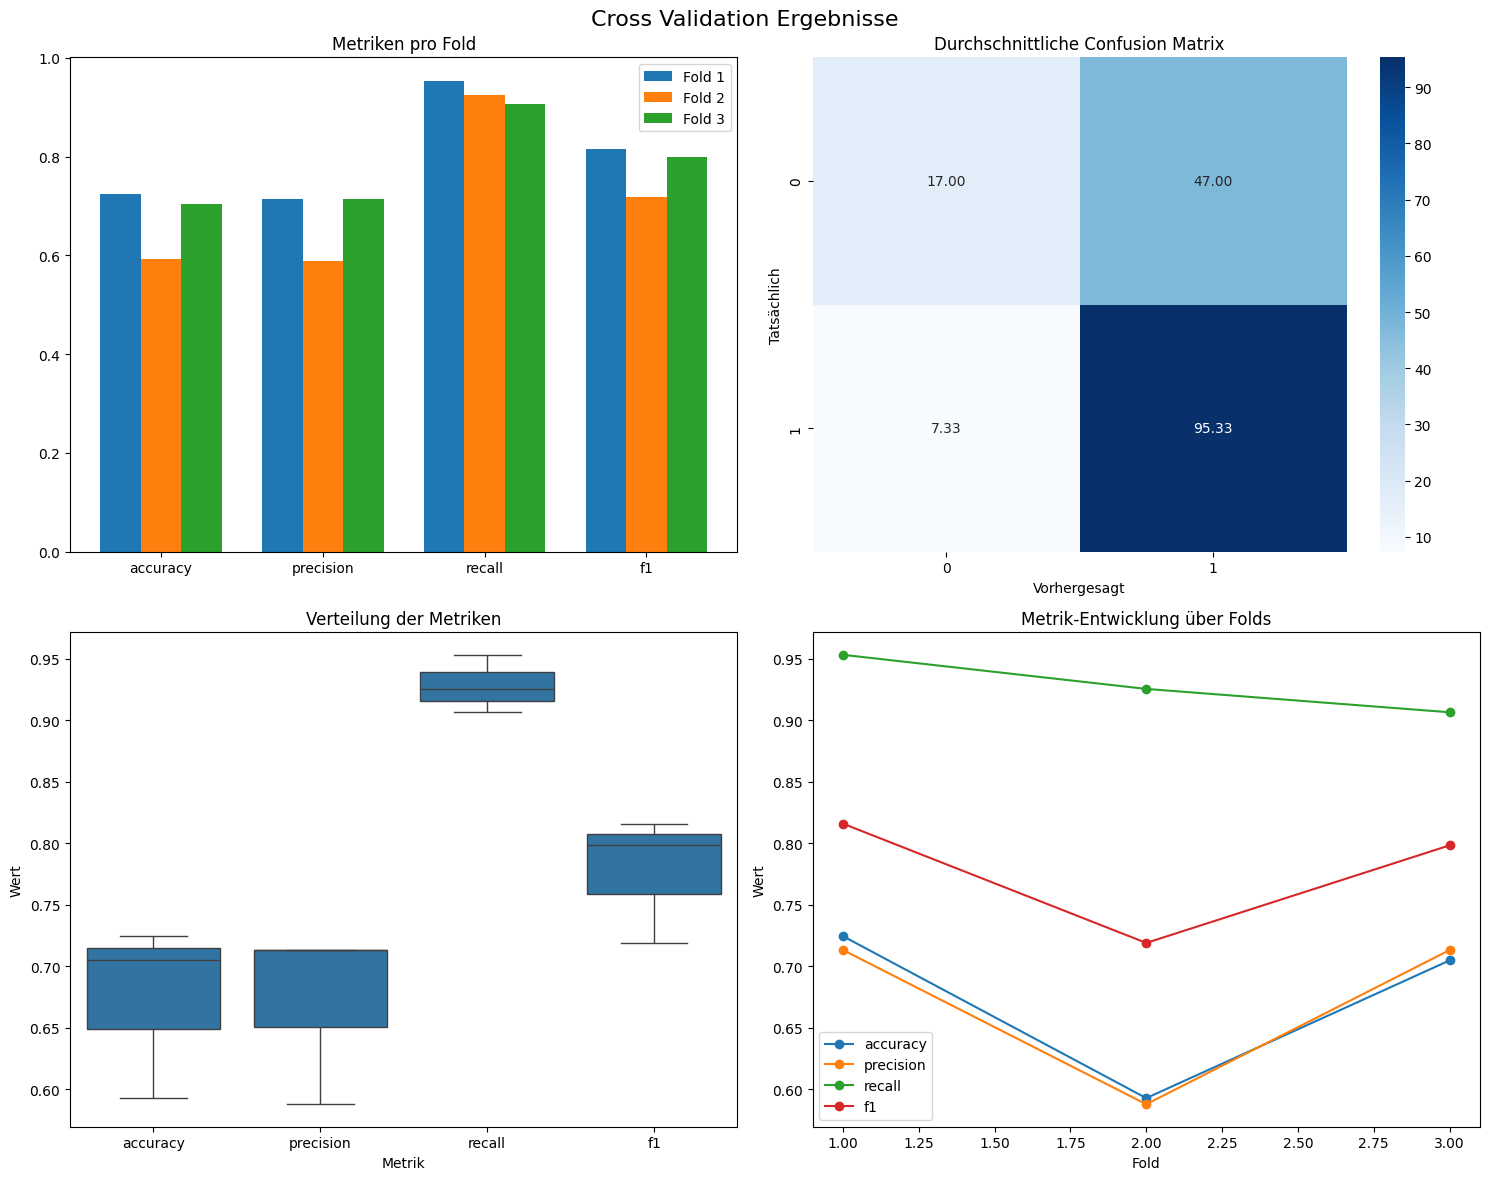


Durchschnittliche Metriken über alle Folds:
--------------------------------------------------
accuracy: 0.6741 (±0.0711)
precision: 0.6715 (±0.0724)
recall: 0.9284 (±0.0235)
f1: 0.7778 (±0.0517)


In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import numpy as np

# CODE VON FÜR CROSS VAL VISUALISIERUNG VON COPILOT:

# Daten laden
df = pd.read_csv('hateData.csv')
df = df.head(500)  # 500 Samples
texts = df['text'].tolist()
labels = (df['label'] == 'hate').astype(int).tolist()

# 3-Fold Cross Validation
kf = KFold(n_splits=3, shuffle=True, random_state=42)

# Listen für alle Metriken
all_metrics = []
all_conf_matrices = []

# Cross Validation durchführen
for fold, (train_idx, test_idx) in enumerate(kf.split(texts), 1):
    test_texts = [texts[i] for i in test_idx]
    test_labels = [labels[i] for i in test_idx]
    
    predictions = []
    for text in test_texts:
        result = predict(text)
        pred = 1 if result[0][1] > 0.5 else 0
        predictions.append(pred)
    
    # Metriken speichern
    metrics = {
        'fold': fold,
        'accuracy': accuracy_score(test_labels, predictions),
        'precision': precision_score(test_labels, predictions),
        'recall': recall_score(test_labels, predictions),
        'f1': f1_score(test_labels, predictions)
    }
    all_metrics.append(metrics)
    
    # Confusion Matrix für diesen Fold
    conf_matrix = confusion_matrix(test_labels, predictions)
    all_conf_matrices.append(conf_matrix)

# Visualisierungen
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Cross Validation Ergebnisse', fontsize=16)

# 1. Metriken pro Fold als Balkendiagramm
metrics_df = pd.DataFrame(all_metrics)
metrics_to_plot = ['accuracy', 'precision', 'recall', 'f1']
bar_positions = np.arange(len(metrics_to_plot))
width = 0.25

for i, fold in enumerate(metrics_df['fold'].unique()):
    fold_data = metrics_df[metrics_df['fold'] == fold]
    axes[0,0].bar(bar_positions + i*width, 
                 [fold_data[metric].iloc[0] for metric in metrics_to_plot],
                 width,
                 label=f'Fold {fold}')

axes[0,0].set_xticks(bar_positions + width)
axes[0,0].set_xticklabels(metrics_to_plot)
axes[0,0].set_title('Metriken pro Fold')
axes[0,0].legend()

# 2. Durchschnittliche Confusion Matrix
avg_conf_matrix = np.mean(all_conf_matrices, axis=0)
sns.heatmap(avg_conf_matrix, annot=True, fmt='.2f', cmap='Blues', ax=axes[0,1])
axes[0,1].set_title('Durchschnittliche Confusion Matrix')
axes[0,1].set_xlabel('Vorhergesagt')
axes[0,1].set_ylabel('Tatsächlich')

# 3. Metrik-Verteilung als Box Plot
metrics_long = pd.melt(metrics_df, id_vars=['fold'], value_vars=metrics_to_plot)
sns.boxplot(x='variable', y='value', data=metrics_long, ax=axes[1,0])
axes[1,0].set_title('Verteilung der Metriken')
axes[1,0].set_xlabel('Metrik')
axes[1,0].set_ylabel('Wert')

# 4. Metrik-Entwicklung über Folds
for metric in metrics_to_plot:
    axes[1,1].plot(metrics_df['fold'], metrics_df[metric], marker='o', label=metric)
axes[1,1].set_title('Metrik-Entwicklung über Folds')
axes[1,1].set_xlabel('Fold')
axes[1,1].set_ylabel('Wert')
axes[1,1].legend()

plt.tight_layout()
plt.show()

# Durchschnittliche Metriken ausgeben
print("\nDurchschnittliche Metriken über alle Folds:")
print("-" * 50)
for metric in metrics_to_plot:
    mean_val = metrics_df[metric].mean()
    std_val = metrics_df[metric].std()
    print(f"{metric}: {mean_val:.4f} (±{std_val:.4f})")